# Pre-Merge Exploratory Data Analysis
## Mortgage Rate Lock-In Effect: State-Level Analysis

**Purpose:** Validate each raw dataset independently before panel construction. Check data quality, coverage, value ranges, distributions, and cross-dataset alignment.

**Files in `data/raw/` (9 CSVs):**

| # | File | Source | Frequency | Key Variables |
|---|------|--------|-----------|---------------|
| 1 | `nmdb-outstanding-mortgage-statistics-states-quarterly.csv` | FHFA NMDB | Quarterly | `AVE_INTRATE`, `PCT_INTRATE_*` |
| 2 | `state_permits.csv` | Census/FRED | Monthly | Building permits by state |
| 3 | `state_hpi.csv` | FHFA/FRED | Quarterly (ffill) | House Price Index by state |
| 4 | `state_unemployment.csv` | BLS/FRED | Monthly | Unemployment rate by state |
| 5 | `national_series.csv` | FRED | Monthly | Mortgage rate, fed funds, PPI, CPI |
| 6 | `State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv` | Zillow | Monthly | Home values by state |
| 7 | `RDC_Inventory_Core_Metrics_State_History.csv` | Realtor.com | Monthly | Listings, inventory, DOM |
| 8 | `nst-est2020-alldata.csv` | Census Bureau | Annual | Migration & pop 2010-2020 |
| 9 | `NST-EST2025-ALLDATA.csv` | Census Bureau | Annual | Migration & pop 2020-2025 |

---

## 0. Setup

In [1]:
import os, warnings
from pathlib import Path as path
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
warnings.filterwarnings("ignore")

sns.set_theme(style="whitegrid", font_scale=1.05)
PAL = {"blue":"#1B3A5C", "acc":"#2E75B6", "red":"#D9534F",
       "green":"#5CB85C", "orange":"#F0AD4E", "gray":"#999999"}

RAW = os.path.join("..", "data", "raw")
EDA = os.path.join("..", "output", "eda")
os.makedirs(EDA, exist_ok=True)

ALL_ST = sorted(["AL","AK","AZ","AR","CA","CO","CT","DE","DC","FL","GA","HI","ID","IL","IN",
    "IA","KS","KY","LA","ME","MD","MA","MI","MN","MS","MO","MT","NE","NV","NH",
    "NJ","NM","NY","NC","ND","OH","OK","OR","PA","RI","SC","SD","TN","TX","UT",
    "VT","VA","WA","WV","WI","WY"])

STATE_NAME_TO_ABBR = {
    "Alabama":"AL","Alaska":"AK","Arizona":"AZ","Arkansas":"AR","California":"CA",
    "Colorado":"CO","Connecticut":"CT","Delaware":"DE","District of Columbia":"DC",
    "Florida":"FL","Georgia":"GA","Hawaii":"HI","Idaho":"ID","Illinois":"IL",
    "Indiana":"IN","Iowa":"IA","Kansas":"KS","Kentucky":"KY","Louisiana":"LA",
    "Maine":"ME","Maryland":"MD","Massachusetts":"MA","Michigan":"MI","Minnesota":"MN",
    "Mississippi":"MS","Missouri":"MO","Montana":"MT","Nebraska":"NE","Nevada":"NV",
    "New Hampshire":"NH","New Jersey":"NJ","New Mexico":"NM","New York":"NY",
    "North Carolina":"NC","North Dakota":"ND","Ohio":"OH","Oklahoma":"OK","Oregon":"OR",
    "Pennsylvania":"PA","Rhode Island":"RI","South Carolina":"SC","South Dakota":"SD",
    "Tennessee":"TN","Texas":"TX","Utah":"UT","Vermont":"VT","Virginia":"VA",
    "Washington":"WA","West Virginia":"WV","Wisconsin":"WI","Wyoming":"WY"
}

coverage = {}

def check_states(states_found, label):
    found = set(states_found) & set(ALL_ST)
    missing = set(ALL_ST) - set(states_found)
    print(f"  States: {len(found)}/51", end="")
    if missing: print(f"  \u26a0 Missing: {sorted(missing)}")
    else: print("  \u2713 All 51 present")
    return missing

print("Setup complete.")

Setup complete.


## 0.1 File Inventory

In [2]:
files = sorted([f for f in os.listdir(RAW) if f.endswith(".csv")])
print(f"Files in data/raw/:  ({len(files)} CSVs)\n")
for f in files:
    kb = os.path.getsize(os.path.join(RAW, f)) / 1024
    print(f"  {f:65s} {kb:>8.1f} KB")

Files in data/raw/:  (9 CSVs)

  NST-EST2025-ALLDATA.csv                                               52.3 KB
  RDC_Inventory_Core_Metrics_State_History.csv                        1648.0 KB
  State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv                291.0 KB
  national_series.csv                                                   13.7 KB
  nmdb-outstanding-mortgage-statistics-states-quarterly.csv          36815.5 KB
  nst-est2020-alldata.csv                                               79.8 KB
  state_hpi.csv                                                        110.4 KB
  state_permits.csv                                                    262.8 KB
  state_unemployment.csv                                                66.4 KB


---
## 1. FHFA Outstanding Mortgage Statistics
`nmdb-outstanding-mortgage-statistics-states-quarterly.csv`

The **most critical dataset**. Contains `AVE_INTRATE` (average outstanding mortgage rate by state/quarter) and rate distribution buckets. This builds the lock-in rate gap variable.

> **Note:** This file is large (~37 MB). If it loads slowly, that is expected.

### 1.1 Load & Basic Structure

In [3]:
fhfa = pd.read_csv(os.path.join(RAW, "nmdb-outstanding-mortgage-statistics-states-quarterly.csv"))
print(f"Shape:       {fhfa.shape[0]:,} rows x {fhfa.shape[1]} cols")
print(f"Duplicates:  {fhfa.duplicated().sum():,}")
print(f"Null cells:  {fhfa.isnull().sum().sum():,}")
print(f"\nColumns: {list(fhfa.columns)}")
print(f"\nGEOLEVEL: {fhfa['GEOLEVEL'].unique()}")
print(f"Period:   {fhfa['PERIOD'].min()} to {fhfa['PERIOD'].max()}")
print(f"Years:    {fhfa['YEAR'].min()} to {fhfa['YEAR'].max()}")
fhfa.head(3)

Shape:       384,948 rows x 14 cols
Duplicates:  0
Null cells:  41,616

Columns: ['SOURCE', 'FREQUENCY', 'GEOLEVEL', 'GEOID', 'GEONAME', 'MARKET', 'PERIOD', 'YEAR', 'QUARTER', 'MONTH', 'SUPPRESSED', 'SERIESID', 'VALUE1', 'VALUE2']

GEOLEVEL: ['State']
Period:   2013Q1 to 2025Q3
Years:    2013 to 2025


,SOURCE,FREQUENCY,GEOLEVEL,GEOID,GEONAME,MARKET,PERIOD,YEAR,QUARTER,MONTH,SUPPRESSED,SERIESID,VALUE1,VALUE2
0,NMDB,Quarterly,State,AK,Alaska,All Mortgages,2013Q1,2013,1,3,0,TOT_LOANS,118.0,NaN
1,NMDB,Quarterly,State,AK,Alaska,All Mortgages,2013Q2,2013,2,6,0,TOT_LOANS,117.0,NaN
2,NMDB,Quarterly,State,AK,Alaska,All Mortgages,2013Q3,2013,3,9,0,TOT_LOANS,117.0,NaN


### 1.2 Available Series IDs

In [4]:
# All unique series and their row counts
fhfa_st = fhfa[fhfa["GEOLEVEL"] == "State"].copy()
print(f"State-level rows: {len(fhfa_st):,}\n")
check_states(fhfa_st["GEOID"].unique(), "FHFA")
print(f"  Periods: {fhfa_st['PERIOD'].nunique()} quarters ({fhfa_st['PERIOD'].min()} to {fhfa_st['PERIOD'].max()})\n")

series_counts = fhfa_st["SERIESID"].value_counts().sort_index()
print(f"{'SERIESID':<30s} {'Rows':>7s}")
print("-" * 40)
for sid, cnt in series_counts.items():
    marker = " <--" if sid in ["AVE_INTRATE","PCT_INTRATE_LT_3","PCT_INTRATE_3_4","PCT_INTRATE_4_5","PCT_INTRATE_5_6","PCT_INTRATE_GE_6","TOT_LOANS"] else ""
    print(f"  {sid:<28s} {cnt:>7,}{marker}")

State-level rows: 384,948

  States: 51/51  ✓ All 51 present
  Periods: 51 quarters (2013Q1 to 2025Q3)

SERIESID                          Rows
----------------------------------------
  AVE_AGE_LOAN                  10,404
  AVE_INTRATE                   10,404 <--
  AVE_MTMLTV                    10,404
  AVE_PAYMENT                   10,404
  AVE_VANTAGESCR                10,404
  PCT_ENTERPRISE                10,404
  PCT_GOVERNMENT                10,404
  PCT_INTRATE_3_4               10,404 <--
  PCT_INTRATE_4_5               10,404 <--
  PCT_INTRATE_5_6               10,404 <--
  PCT_INTRATE_GE_6              10,404 <--
  PCT_INTRATE_LT_3              10,404 <--
  PCT_LOANS                     10,404
  PCT_MTMLTV_61_70              10,404
  PCT_MTMLTV_71_80              10,404
  PCT_MTMLTV_81_90              10,404
  PCT_MTMLTV_91_100             10,404
  PCT_MTMLTV_GT100              10,404
  PCT_MTMLTV_LE60               10,404
  PCT_OTHER                     10,404
  PCT_TENURE

### 1.3 `AVE_INTRATE` Deep Dive
This is the variable subtracted from the current 30-year rate to compute each state's **rate gap**.

In [5]:
ave = fhfa_st[fhfa_st["SERIESID"] == "AVE_INTRATE"].copy()
print(f"Rows: {len(ave):,}  |  States: {ave['GEOID'].nunique()}  |  Quarters: {ave['PERIOD'].nunique()}")
print(f"\nVALUE1 (interest rate) statistics:")
desc = ave["VALUE1"].describe()
for idx in desc.index:
    print(f"  {idx:>8s}: {desc[idx]:.3f}")

med = ave["VALUE1"].median()
if med > 20:
    print(f"\n\u26a0 Median={med:.0f} - VALUES MAY BE IN BASIS POINTS. Divide by 100.")
elif 2.5 < med < 8:
    print(f"\n\u2713 Median={med:.2f}% - units confirmed as percentage. Plausible range.")
else:
    print(f"\n\u26a0 Median={med:.2f} - unusual range, investigate.")

Rows: 10,404  |  States: 51  |  Quarters: 51

VALUE1 (interest rate) statistics:
     count: 10404.000
      mean: 4.563
       std: 0.641
       min: 3.200
       25%: 4.100
       50%: 4.400
       75%: 4.900
       max: 7.600

✓ Median=4.40% - units confirmed as percentage. Plausible range.


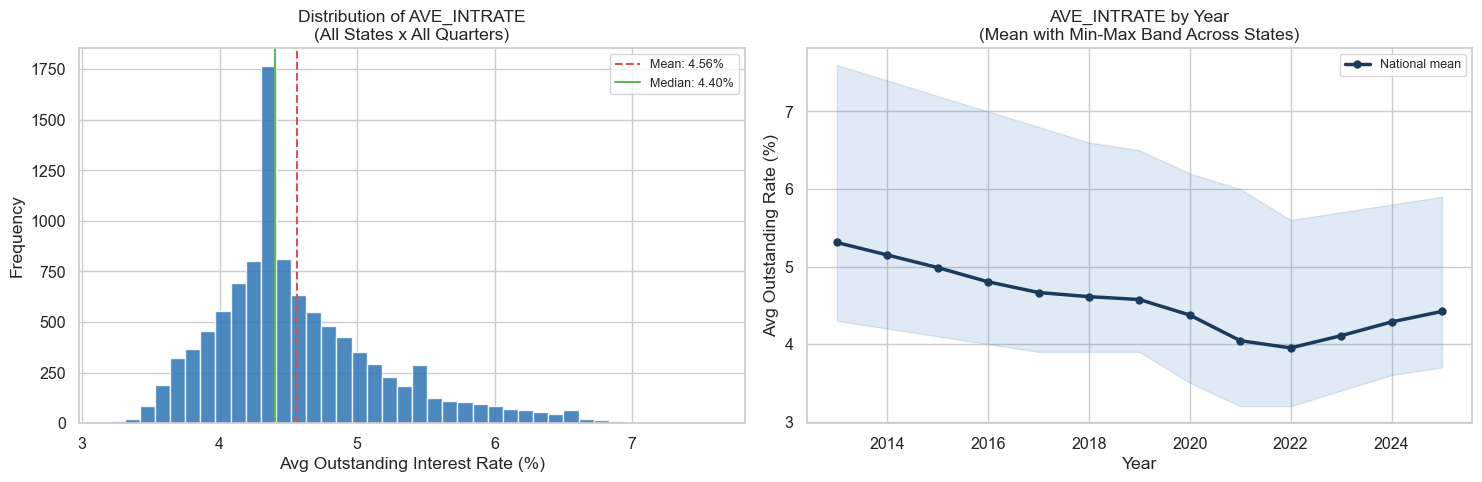

In [6]:
# Distribution + yearly trend
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].hist(ave["VALUE1"], bins=40, color=PAL["acc"], edgecolor="white", alpha=0.85)
axes[0].axvline(ave["VALUE1"].mean(), color=PAL["red"], ls="--", lw=1.5, label=f'Mean: {ave["VALUE1"].mean():.2f}%')
axes[0].axvline(ave["VALUE1"].median(), color=PAL["green"], ls="-", lw=1.5, label=f'Median: {ave["VALUE1"].median():.2f}%')
axes[0].set_xlabel("Avg Outstanding Interest Rate (%)"); axes[0].set_ylabel("Frequency")
axes[0].set_title("Distribution of AVE_INTRATE\n(All States x All Quarters)"); axes[0].legend(fontsize=9)

yearly = ave.groupby("YEAR")["VALUE1"].agg(["mean","min","max"])
axes[1].fill_between(yearly.index, yearly["min"], yearly["max"], alpha=0.15, color=PAL["acc"])
axes[1].plot(yearly.index, yearly["mean"], color=PAL["blue"], lw=2.5, marker="o", ms=5, label="National mean")
axes[1].set_xlabel("Year"); axes[1].set_ylabel("Avg Outstanding Rate (%)")
axes[1].set_title("AVE_INTRATE by Year\n(Mean with Min-Max Band Across States)")
axes[1].legend(fontsize=9)

plt.tight_layout(); plt.savefig(os.path.join(EDA, "01_fhfa_ave_intrate_dist.png"), dpi=150, bbox_inches="tight"); plt.show()

### 1.4 `AVE_INTRATE` by State Over Time

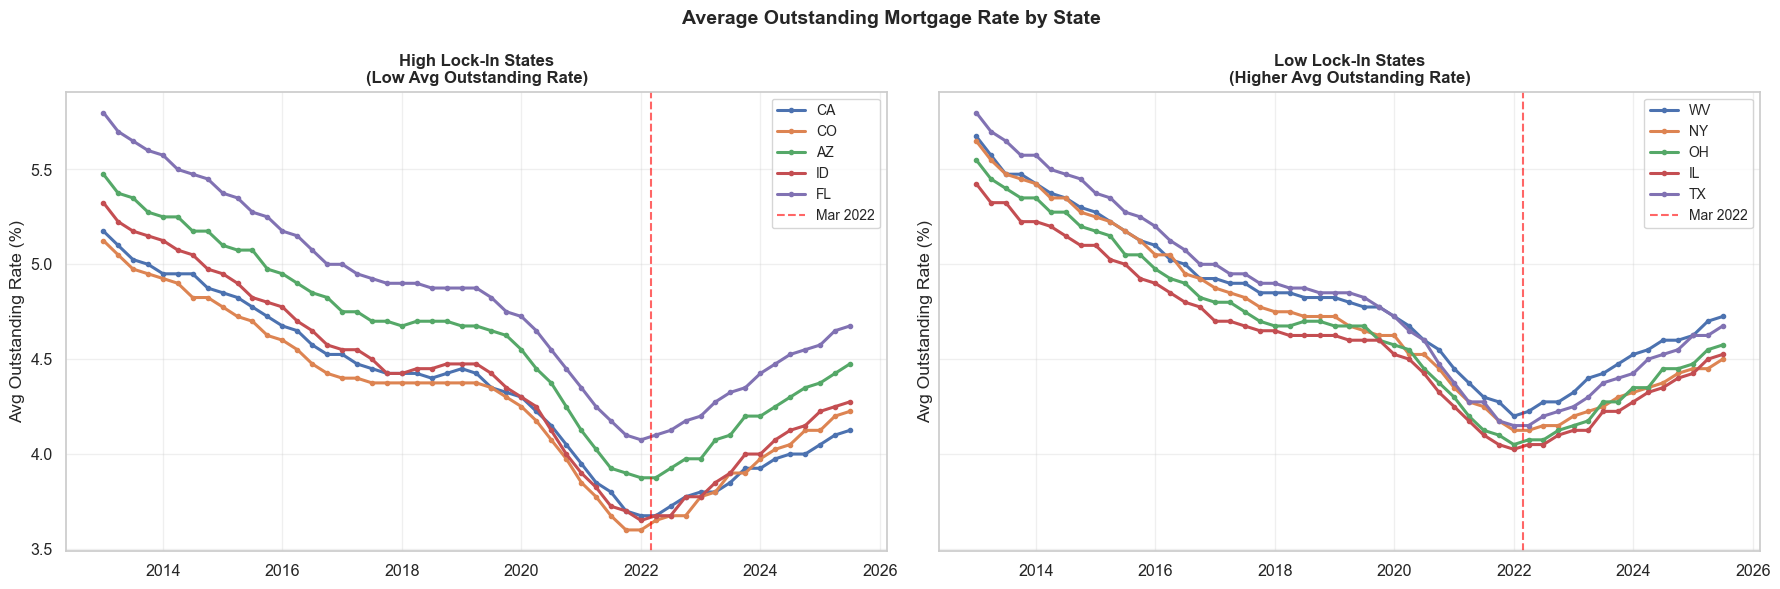

As of 2025Q3:

Most locked-in (LOWEST avg outstanding rate = BIGGEST gap):
  HI: 4.05%
  CA: 4.12%
  MA: 4.17%
  DC: 4.20%
  WA: 4.20%
  OR: 4.20%
  CO: 4.22%
  ID: 4.28%

Least locked-in (HIGHEST avg outstanding rate = SMALLEST gap):
  AR: 4.75%
  LA: 4.75%
  OK: 4.80%
  AL: 4.80%
  MS: 4.92%


In [9]:
ave["date"] = pd.PeriodIndex(ave["PERIOD"], freq="Q").to_timestamp()

# Collapse duplicates: one value per state per quarter
ave_clean = ave.groupby(["GEOID","date"])["VALUE1"].mean().reset_index()

fig, axes = plt.subplots(1, 2, figsize=(18, 6), sharey=True)

high_lock = ["CA","CO","AZ","ID","FL"]
low_lock  = ["WV","NY","OH","IL","TX"]

for st in high_lock:
    sub = ave_clean[ave_clean["GEOID"]==st].sort_values("date")
    axes[0].plot(sub["date"], sub["VALUE1"], label=st, lw=2.2, marker="o", ms=3)

for st in low_lock:
    sub = ave_clean[ave_clean["GEOID"]==st].sort_values("date")
    axes[1].plot(sub["date"], sub["VALUE1"], label=st, lw=2.2, marker="o", ms=3)

for ax, title in zip(axes, ["High Lock-In States\n(Low Avg Outstanding Rate)",
                              "Low Lock-In States\n(Higher Avg Outstanding Rate)"]):
    ax.axvline(pd.Timestamp("2022-03-01"), color="red", ls="--", lw=1.5, alpha=0.6, label="Mar 2022")
    ax.set_ylabel("Avg Outstanding Rate (%)")
    ax.set_title(title, fontsize=12, fontweight="bold")
    ax.legend(fontsize=10)
    ax.grid(True, alpha=0.3)

plt.suptitle("Average Outstanding Mortgage Rate by State", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.savefig(os.path.join(EDA, "02_fhfa_ave_intrate_states.png"), dpi=150, bbox_inches="tight")
plt.show()

# Locked-in ranking
latest_q = ave["PERIOD"].max()
latest = (ave[ave["PERIOD"]==latest_q]
          .groupby("GEOID")["VALUE1"].mean().sort_values())

print(f"As of {latest_q}:\n")
print("Most locked-in (LOWEST avg outstanding rate = BIGGEST gap):")
for st, val in latest.head(8).items():
    print(f"  {st}: {val:.2f}%")
print(f"\nLeast locked-in (HIGHEST avg outstanding rate = SMALLEST gap):")
for st, val in latest.tail(5).items():
    print(f"  {st}: {val:.2f}%")

### 1.5 Rate Distribution Buckets

In [10]:
buckets = ["PCT_INTRATE_LT_3","PCT_INTRATE_3_4","PCT_INTRATE_4_5","PCT_INTRATE_5_6","PCT_INTRATE_GE_6"]
bucket_labels = ["< 3%", "3-4%", "4-5%", "5-6%", "\u2265 6%"]

print(f"{'Bucket':<25s} {'Rows':>7s} {'Mean':>8s} {'Min':>8s} {'Max':>8s}")
print("-" * 60)
for b in buckets:
    d = fhfa_st[fhfa_st["SERIESID"]==b]["VALUE1"]
    print(f"  {b:<23s} {len(d):>7,} {d.mean():>8.2f} {d.min():>8.2f} {d.max():>8.2f}")

# Sum check
bp = fhfa_st[fhfa_st["SERIESID"].isin(buckets)].pivot_table(
    index=["GEOID","PERIOD"], columns="SERIESID", values="VALUE1")
avail = [b for b in buckets if b in bp.columns]
bp["total"] = bp[avail].sum(axis=1)
print(f"\nBucket sum check ({len(avail)} buckets):")
print(f"  Mean: {bp['total'].mean():.2f}  |  Min: {bp['total'].min():.2f}  |  Max: {bp['total'].max():.2f}")
if abs(bp["total"].mean() - 100) < 2:
    print("  \u2713 Buckets sum to ~100%. Data is internally consistent.")
else:
    print(f"  \u26a0 Mean sum = {bp['total'].mean():.1f}% - investigate.")

Bucket                       Rows     Mean      Min      Max
------------------------------------------------------------
  PCT_INTRATE_LT_3         10,404    10.40     0.10    54.00
  PCT_INTRATE_3_4          10,404    31.77     4.30    59.00
  PCT_INTRATE_4_5          10,404    26.99     7.00    52.20
  PCT_INTRATE_5_6          10,404    13.24     2.10    32.60
  PCT_INTRATE_GE_6         10,404    17.60     1.30    72.60

Bucket sum check (5 buckets):
  Mean: 100.00  |  Min: 99.88  |  Max: 100.10
  ✓ Buckets sum to ~100%. Data is internally consistent.


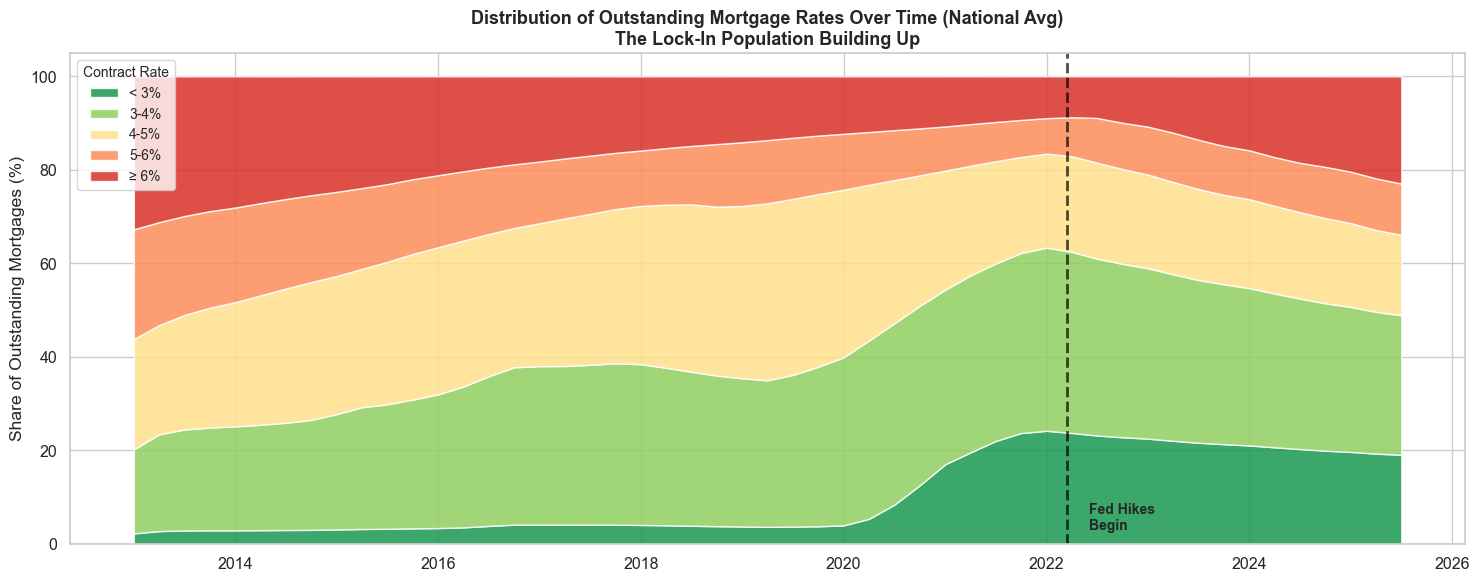

Share of mortgages < 5% as of 2025Q3 (most locked-in states):
  HI: 74.4%
  CA: 73.4%
  MA: 72.7%
  OR: 71.8%
  WA: 71.5%
  DC: 71.0%
  MN: 70.5%
  CO: 70.3%


In [11]:
# Stacked area: rate distribution over time
rd = fhfa_st[fhfa_st["SERIESID"].isin(buckets)].copy()
rd["date"] = pd.PeriodIndex(rd["PERIOD"], freq="Q").to_timestamp()
natl = rd.groupby(["date","SERIESID"])["VALUE1"].mean().unstack()
natl = natl[[b for b in buckets if b in natl.columns]].sort_index()

fig, ax = plt.subplots(figsize=(15, 6))
colors = ["#1a9850","#91cf60","#fee08b","#fc8d59","#d73027"]
ax.stackplot(natl.index, *[natl[col] for col in natl.columns],
             labels=bucket_labels[:len(natl.columns)], colors=colors[:len(natl.columns)], alpha=0.85)
ax.axvline(pd.Timestamp("2022-03-16"), color="black", ls="--", lw=2, alpha=0.7)
ax.text(pd.Timestamp("2022-06-01"), 3, "Fed Hikes\nBegin", fontsize=10, fontweight="bold")
ax.set_ylabel("Share of Outstanding Mortgages (%)"); ax.set_ylim(0, 105)
ax.set_title("Distribution of Outstanding Mortgage Rates Over Time (National Avg)\nThe Lock-In Population Building Up",
             fontsize=13, fontweight="bold")
ax.legend(loc="upper left", title="Contract Rate", fontsize=10, title_fontsize=10)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "03_fhfa_rate_dist_stacked.png"), dpi=150, bbox_inches="tight"); plt.show()

# Compute share locked in (< 5%) for latest quarter
locked = bp[["PCT_INTRATE_LT_3","PCT_INTRATE_3_4","PCT_INTRATE_4_5"]].sum(axis=1)
locked.name = "share_locked_in"
locked_latest = locked.xs(latest_q, level="PERIOD").sort_values(ascending=False)
print(f"Share of mortgages < 5% as of {latest_q} (most locked-in states):")
for st in locked_latest.head(8).index:
    print(f"  {st}: {locked_latest[st]:.1f}%")

coverage["FHFA Rates"] = {"states":51, "start":"2013 Q1", "end":latest_q, "freq":"Quarterly"}

---
## 2. Building Permits (Census/FRED)
`state_permits.csv` — Wide format: rows = months, columns = 51 state abbreviations. Seasonally adjusted.

In [12]:
permits = pd.read_csv(os.path.join(RAW, "state_permits.csv"), index_col=0, parse_dates=True)
print(f"Shape:  {permits.shape[0]} months x {permits.shape[1]} states")
print(f"Range:  {permits.index.min().date()} to {permits.index.max().date()}")
print(f"Nulls:  {permits.isnull().sum().sum()}  |  Negatives: {(permits<0).sum().sum()}")
check_states(permits.columns, "Permits")

avg = permits.mean().sort_values(ascending=False)
print(f"\nTop 5 by avg monthly permits:    {', '.join([f'{s} ({avg[s]:,.0f})' for s in avg.head(5).index])}")
print(f"Bottom 5 by avg monthly permits: {', '.join([f'{s} ({avg[s]:,.0f})' for s in avg.tail(5).index])}")
print(f"\nNational total (avg month): {permits.sum(axis=1).mean():,.0f}")

coverage["Permits"] = {"states":51, "start":str(permits.index.min().date()), 
                        "end":str(permits.index.max().date()), "freq":"Monthly"}

Shape:  312 months x 51 states
Range:  2000-01-01 to 2025-12-01
Nulls:  1  |  Negatives: 0
  States: 51/51  ✓ All 51 present

Top 5 by avg monthly permits:    TX (14,372), FL (11,836), CA (9,238), NC (5,851), GA (5,014)
Bottom 5 by avg monthly permits: DC (263), WY (181), VT (171), AK (143), RI (127)

National total (avg month): 111,652


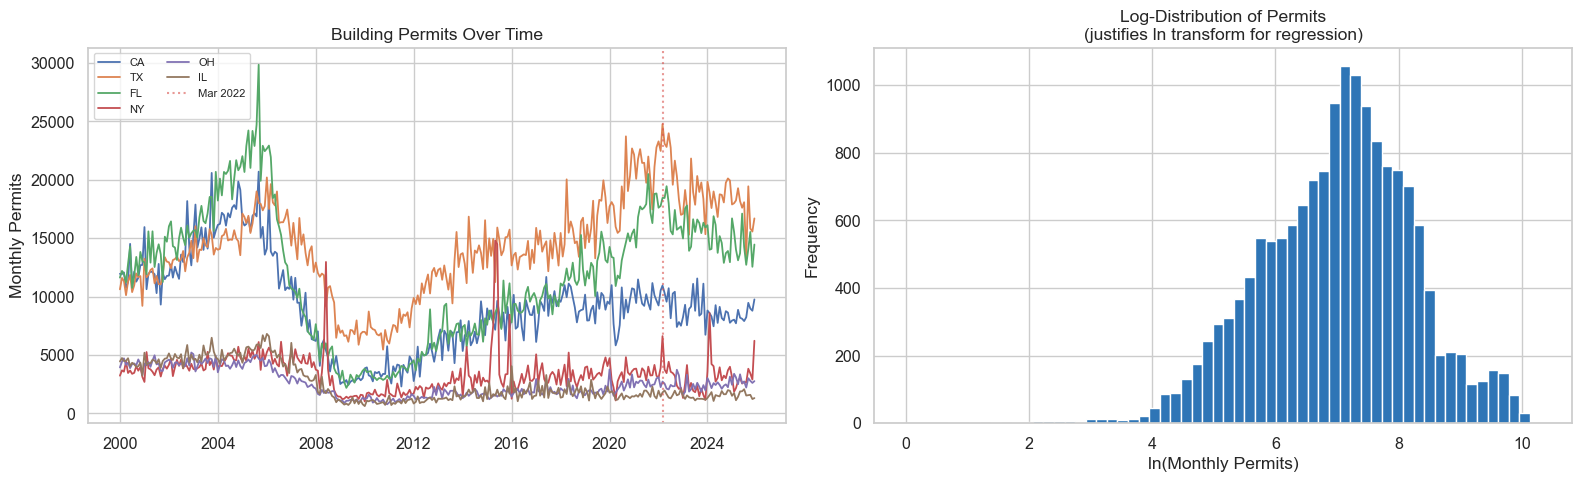

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for st in ["CA","TX","FL","NY","OH","IL"]:
    axes[0].plot(permits.index, permits[st], label=st, lw=1.3)
axes[0].axvline(pd.Timestamp("2022-03-01"), color=PAL["red"], ls=":", alpha=0.6, label="Mar 2022")
axes[0].set_title("Building Permits Over Time"); axes[0].set_ylabel("Monthly Permits")
axes[0].legend(fontsize=8, ncol=2)

vals = permits.values.flatten(); vals = vals[~np.isnan(vals)]
axes[1].hist(np.log1p(vals), bins=60, color=PAL["acc"], edgecolor="white")
axes[1].set_xlabel("ln(Monthly Permits)"); axes[1].set_ylabel("Frequency")
axes[1].set_title("Log-Distribution of Permits\n(justifies ln transform for regression)")

plt.tight_layout(); plt.savefig(os.path.join(EDA, "04_permits_overview.png"), dpi=150, bbox_inches="tight"); plt.show()

---
## 3. FHFA House Price Index
`state_hpi.csv` — Quarterly index forward-filled to monthly. Control variable (demand signal).

In [14]:
hpi = pd.read_csv(os.path.join(RAW, "state_hpi.csv"), index_col=0, parse_dates=True)
print(f"Shape: {hpi.shape[0]} months x {hpi.shape[1]} states")
print(f"Range: {hpi.index.min().date()} to {hpi.index.max().date()}")
print(f"Nulls: {hpi.isnull().sum().sum()}")
check_states(hpi.columns, "HPI")

vals = hpi.values.flatten(); vals = vals[~np.isnan(vals)]
print(f"\nIndex range: {vals.min():.1f} to {vals.max():.1f}")

# Confirm forward-fill (first 6 months of CA should repeat in groups of 3)
sample = hpi["CA"].head(6).values
repeats = sum(1 for i in range(1,len(sample)) if sample[i]==sample[i-1])
print(f"Forward-fill check (CA first 6 months): {repeats} consecutive equal pairs", end="")
print(" \u2713" if repeats >= 2 else " \u26a0 check")

# YoY growth for recent period
hpi_yoy = hpi.pct_change(12) * 100
recent = hpi_yoy.iloc[-1].sort_values()
print(f"\nYoY HPI growth as of {hpi.index[-1].date()}:")
print(f"  Fastest:  {recent.index[-1]} ({recent.iloc[-1]:+.1f}%),  {recent.index[-2]} ({recent.iloc[-2]:+.1f}%)")
print(f"  Slowest:  {recent.index[0]} ({recent.iloc[0]:+.1f}%),  {recent.index[1]} ({recent.iloc[1]:+.1f}%)")

coverage["FHFA HPI"] = {"states":51, "start":str(hpi.index.min().date()),
                          "end":str(hpi.index.max().date()), "freq":"Quarterly (ffill)"}

Shape: 310 months x 51 states
Range: 2000-01-01 to 2025-10-01
Nulls: 0
  States: 51/51  ✓ All 51 present

Index range: 144.2 to 1304.0
Forward-fill check (CA first 6 months): 4 consecutive equal pairs ✓

YoY HPI growth as of 2025-10-01:
  Fastest:  HI (+7.1%),  IL (+6.4%)
  Slowest:  FL (+0.0%),  TX (+1.1%)


---
## 4. State Unemployment Rates (BLS/FRED)
`state_unemployment.csv` — Monthly, all 51 states.

In [15]:
unemp = pd.read_csv(os.path.join(RAW, "state_unemployment.csv"), index_col=0, parse_dates=True)
print(f"Shape: {unemp.shape[0]} months x {unemp.shape[1]} states")
print(f"Range: {unemp.index.min().date()} to {unemp.index.max().date()}")
print(f"Nulls: {unemp.isnull().sum().sum()}")
check_states(unemp.columns, "Unemployment")

vals = unemp.values.flatten(); vals = vals[~np.isnan(vals)]
print(f"\nRange: {vals.min():.1f}% to {vals.max():.1f}%")

# Find the COVID spike
max_idx = unemp.stack().idxmax()
print(f"Maximum: {vals.max():.1f}% at {max_idx[0].date()}, {max_idx[1]}")
if vals.max() > 20:
    print("  \u26a0 COVID spike detected (expected). Consider a COVID dummy for 2020 Q2-Q3.")

# Current snapshot
latest_u = unemp.iloc[-1].sort_values()
print(f"\nAs of {unemp.index[-1].date()}:")
print(f"  Lowest:  {latest_u.index[0]} ({latest_u.iloc[0]:.1f}%), {latest_u.index[1]} ({latest_u.iloc[1]:.1f}%)")
print(f"  Highest: {latest_u.index[-1]} ({latest_u.iloc[-1]:.1f}%), {latest_u.index[-2]} ({latest_u.iloc[-2]:.1f}%)")

coverage["Unemployment"] = {"states":51, "start":str(unemp.index.min().date()),
                              "end":str(unemp.index.max().date()), "freq":"Monthly"}

Shape: 312 months x 51 states
Range: 2000-01-01 to 2025-12-01
Nulls: 51
  States: 51/51  ✓ All 51 present

Range: 1.7% to 30.5%
Maximum: 30.5% at 2020-04-01, NV
  ⚠ COVID spike detected (expected). Consider a COVID dummy for 2020 Q2-Q3.

As of 2025-12-01:
  Lowest:  HI (2.2%), SD (2.2%)
  Highest: DC (6.7%), CA (5.5%)


---
## 5. National Macro Series (FRED)
`national_series.csv` — Monthly: mortgage rate, fed funds, lumber PPI, construction inputs PPI, CPI shelter.

In [16]:
natl = pd.read_csv(os.path.join(RAW, "national_series.csv"), index_col=0, parse_dates=True)
print(f"Shape: {natl.shape[0]} months x {natl.shape[1]} cols")
print(f"Range: {natl.index.min().date()} to {natl.index.max().date()}")
print(f"\nNull counts:")
for col in natl.columns:
    print(f"  {col:<30s}  {natl[col].isnull().sum()}")

print(f"\nKey statistics:")
for col in natl.columns:
    s = natl[col].dropna()
    print(f"  {col:<30s}  min={s.min():.2f}  max={s.max():.2f}  latest={s.iloc[-1]:.2f}")

coverage["National"] = {"states":"N/A", "start":str(natl.index.min().date()),
                         "end":str(natl.index.max().date()), "freq":"Monthly"}

Shape: 312 months x 5 cols
Range: 2000-01-01 to 2025-12-01

Null counts:
  mortgage_rate_30yr              0
  fed_funds_rate                  0
  ppi_lumber                      0
  ppi_construction_inputs         0
  cpi_shelter                     1

Key statistics:
  mortgage_rate_30yr              min=2.68  max=8.52  latest=6.19
  fed_funds_rate                  min=0.05  max=6.54  latest=3.72
  ppi_lumber                      min=133.90  max=581.50  latest=250.17
  ppi_construction_inputs         min=141.70  max=353.01  latest=344.75
  cpi_shelter                     min=190.60  max=421.04  latest=421.04


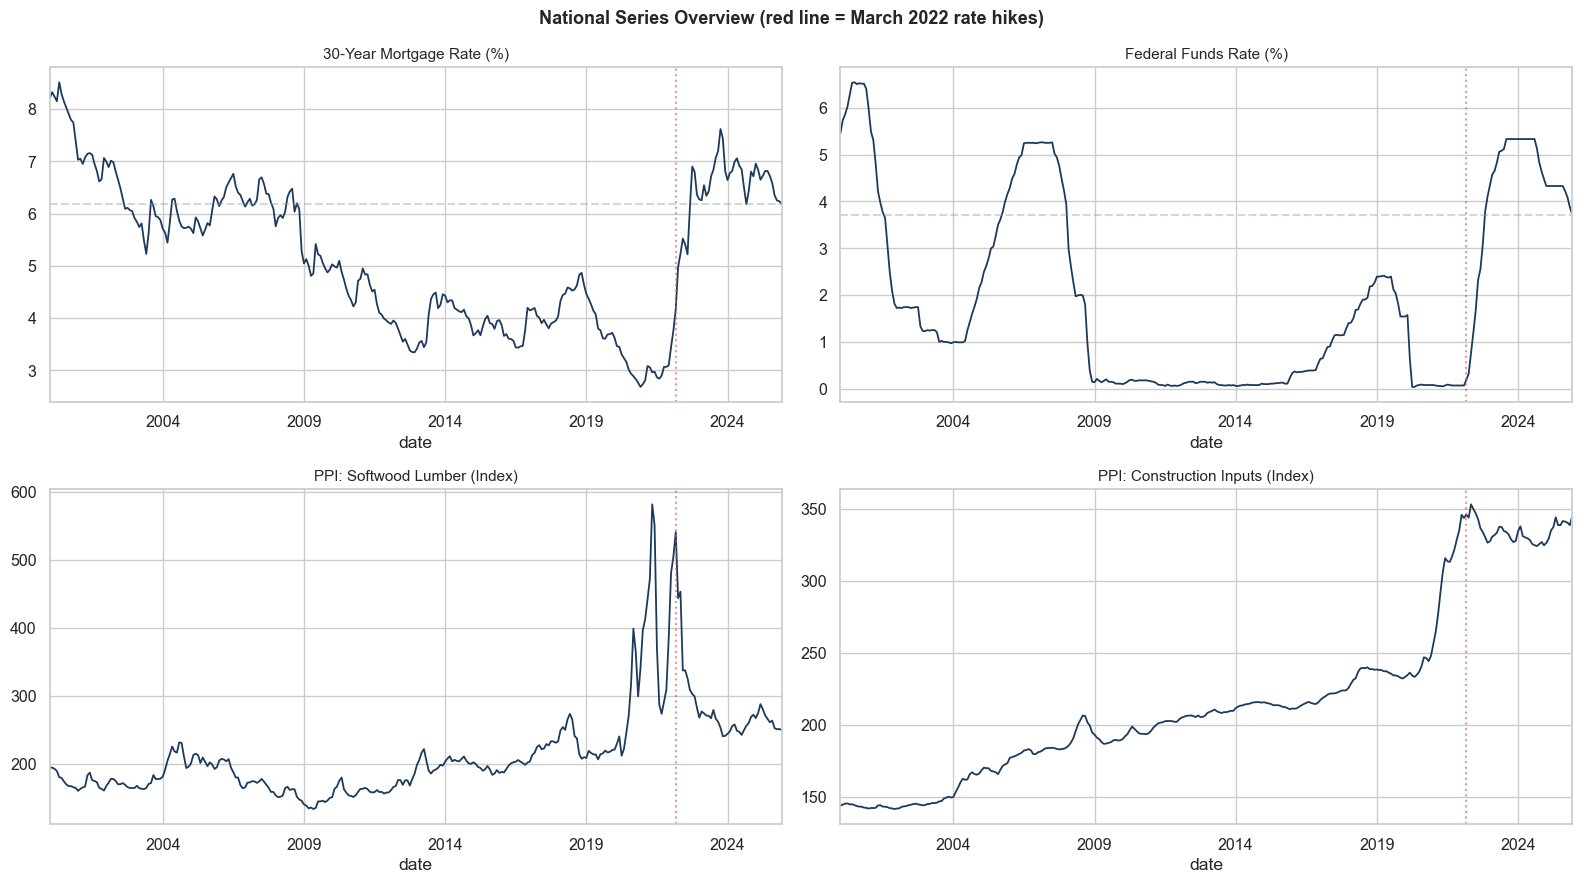

In [17]:
fig, axes = plt.subplots(2, 2, figsize=(16, 9))
configs = [
    ("mortgage_rate_30yr", "30-Year Mortgage Rate (%)", True),
    ("fed_funds_rate", "Federal Funds Rate (%)", True),
    ("ppi_lumber", "PPI: Softwood Lumber (Index)", False),
    ("ppi_construction_inputs", "PPI: Construction Inputs (Index)", False),
]
for i, (col, title, show_hline) in enumerate(configs):
    ax = axes[i//2][i%2]
    natl[col].dropna().plot(ax=ax, color=PAL["blue"], lw=1.3)
    ax.axvline(pd.Timestamp("2022-03-01"), color=PAL["red"], ls=":", alpha=0.6)
    ax.set_title(title, fontsize=11)
    if show_hline:
        ax.axhline(y=natl[col].dropna().iloc[-1], color=PAL["gray"], ls="--", alpha=0.4)

plt.suptitle("National Series Overview (red line = March 2022 rate hikes)", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "05_national_series.png"), dpi=150, bbox_inches="tight"); plt.show()

---
## 6. Zillow Home Value Index (ZHVI)
`State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv` — 51 states, monthly home values in dollars.

In [18]:
zillow = pd.read_csv(os.path.join(RAW, "State_zhvi_uc_sfrcondo_tier_0.33_0.67_sm_sa_month.csv"))
date_cols = [c for c in zillow.columns if c[:4].isdigit()]
print(f"Shape: {len(zillow)} states x {len(date_cols)} months")
print(f"Date range: {date_cols[0]} to {date_cols[-1]}")
print(f"Nulls in values: {zillow[date_cols].isnull().sum().sum()}")

# Latest values
latest_col = date_cols[-1]
vals = zillow.set_index("RegionName")[latest_col].sort_values()
print(f"\nHome values as of {latest_col}:")
print(f"  Most expensive:  {vals.index[-1]} (${vals.iloc[-1]:,.0f}), {vals.index[-2]} (${vals.iloc[-2]:,.0f})")
print(f"  Least expensive: {vals.index[0]} (${vals.iloc[0]:,.0f}), {vals.index[1]} (${vals.iloc[1]:,.0f})")
print(f"  National median:  ${vals.median():,.0f}")

# Null states (which states have missing early data?)
null_by_state = zillow.set_index("RegionName")[date_cols].isnull().sum(axis=1)
if null_by_state.sum() > 0:
    print(f"\nStates with missing months:")
    for st in null_by_state[null_by_state > 0].index:
        print(f"  {st}: {null_by_state[st]} missing months")

coverage["Zillow ZHVI"] = {"states":51, "start":date_cols[0], "end":date_cols[-1], "freq":"Monthly"}

Shape: 51 states x 314 months
Date range: 2000-01-31 to 2026-02-28
Nulls in values: 228

Home values as of 2026-02-28:
  Most expensive:  Hawaii ($823,970), California ($765,036)
  Least expensive: West Virginia ($169,780), Mississippi ($189,895)
  National median:  $341,308

States with missing months:
  Arizona: 1 missing months
  New Mexico: 27 missing months
  Idaho: 1 missing months
  West Virginia: 1 missing months
  Montana: 61 missing months
  South Dakota: 1 missing months
  North Dakota: 108 missing months
  Alaska: 1 missing months
  Wyoming: 27 missing months


---
## 7. Realtor.com Inventory & Listings
`RDC_Inventory_Core_Metrics_State_History.csv` — Monthly, long format. Contains `new_listing_count` (primary DV) and `active_listing_count`.

In [19]:
rdc = pd.read_csv(os.path.join(RAW, "RDC_Inventory_Core_Metrics_State_History.csv"))
rdc["date"] = pd.to_datetime(rdc["month_date_yyyymm"].astype(str), format="%Y%m")
print(f"Shape: {len(rdc):,} rows x {rdc.shape[1]} cols")
print(f"Date range: {rdc['date'].min().date()} to {rdc['date'].max().date()}")
print(f"Duplicates: {rdc.duplicated().sum()}")
check_states(rdc["state_id"].unique(), "Realtor.com")

key_cols = ["new_listing_count","active_listing_count","median_days_on_market",
            "median_listing_price","pending_listing_count","price_reduced_count"]
print(f"\n{'Variable':<35s} {'Nulls':>6s} {'Mean':>14s} {'Min':>12s} {'Max':>14s}")
print("-" * 85)
for col in key_cols:
    if col in rdc.columns:
        s = rdc[col]
        print(f"  {col:<33s} {s.isnull().sum():>6} {s.mean():>14,.1f} {s.min():>12,.0f} {s.max():>14,.0f}")

coverage["Realtor.com"] = {"states":51, "start":str(rdc["date"].min().date()),
                            "end":str(rdc["date"].max().date()), "freq":"Monthly"}

Shape: 5,916 rows x 47 cols
Date range: 2016-07-01 to 2026-02-01
Duplicates: 0
  States: 51/51  ✓ All 51 present

Variable                             Nulls           Mean          Min            Max
-------------------------------------------------------------------------------------
  new_listing_count                      0        8,117.3          290         53,332
  active_listing_count                   0       17,827.8          720        182,589
  median_days_on_market                  0           59.0           13            157
  median_listing_price                   0      365,608.6      129,913        886,500
  pending_listing_count                 27        8,503.9            0         82,071
  price_reduced_count                    0        5,225.5           72         71,888


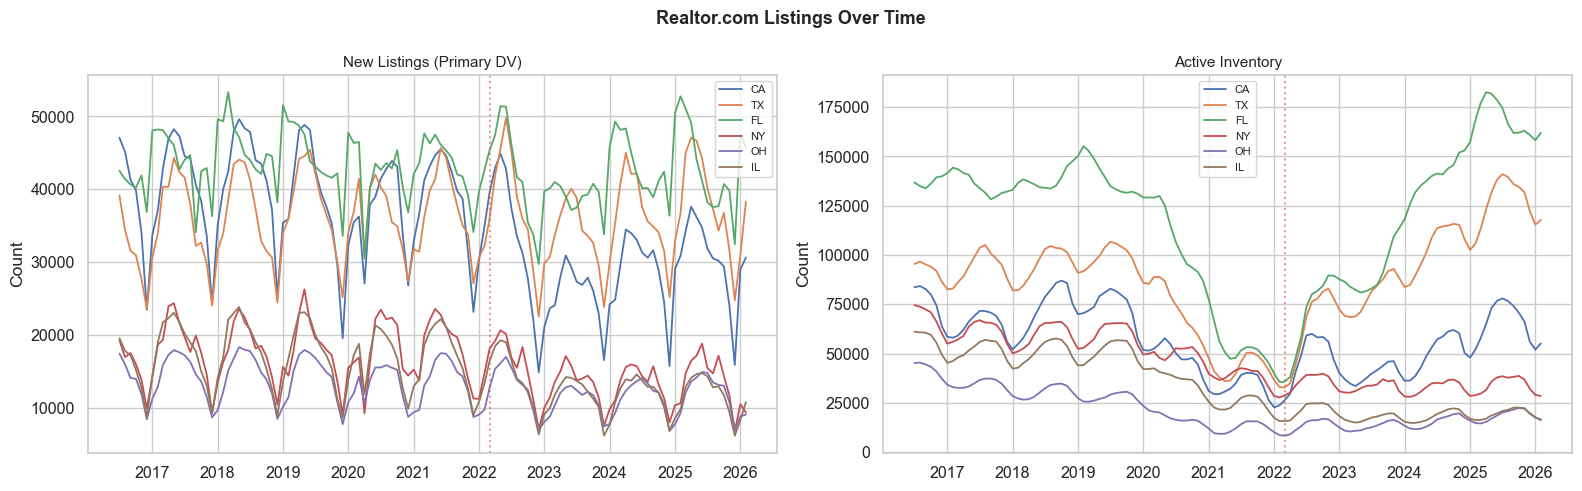

In [20]:
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for st in ["CA","TX","FL","NY","OH","IL"]:
    sub = rdc[rdc["state_id"]==st].sort_values("date")
    axes[0].plot(sub["date"], sub["new_listing_count"], label=st, lw=1.3)
    axes[1].plot(sub["date"], sub["active_listing_count"], label=st, lw=1.3)

for ax, title in zip(axes, ["New Listings (Primary DV)", "Active Inventory"]):
    ax.axvline(pd.Timestamp("2022-03-01"), color=PAL["red"], ls=":", alpha=0.6)
    ax.set_title(title, fontsize=11); ax.legend(fontsize=8); ax.set_ylabel("Count")

plt.suptitle("Realtor.com Listings Over Time", fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "06_realtor_listings.png"), dpi=150, bbox_inches="tight"); plt.show()

---
## 8. Census Net Domestic Migration
`nst-est2020-alldata.csv` (2010-2020) + `NST-EST2025-ALLDATA.csv` (2020-2025)

Annual net domestic migration by state. Used as lagged control variable. The `RDOMESTICMIG` columns are already per-1,000 population rates.

In [21]:
# Load both vintages
c10 = pd.read_csv(os.path.join(RAW, "nst-est2020-alldata.csv"))
c20 = pd.read_csv(os.path.join(RAW, "NST-EST2025-ALLDATA.csv"))

# Filter to states (SUMLEV=40), exclude Puerto Rico
c10_st = c10[(c10["SUMLEV"]==40) & (c10["NAME"]!="Puerto Rico")].copy()
c20_st = c20[(c20["SUMLEV"]==40) & (c20["NAME"]!="Puerto Rico")].copy()

print(f"2010-2020 vintage: {len(c10_st)} states")
print(f"2020-2025 vintage: {len(c20_st)} states")
print()
check_states([STATE_NAME_TO_ABBR.get(n,"??") for n in c10_st["NAME"]], "Census 2010-2020")
check_states([STATE_NAME_TO_ABBR.get(n,"??") for n in c20_st["NAME"]], "Census 2020-2025")

# Extract RDOMESTICMIG columns (rate per 1,000)
rdom10 = [c for c in c10_st.columns if c.startswith("RDOMESTICMIG")]
rdom20 = [c for c in c20_st.columns if c.startswith("RDOMESTICMIG")]
print(f"\n2010s rate columns: {rdom10}")
print(f"2020s rate columns: {rdom20}")

# Also get raw counts
dom10 = [c for c in c10_st.columns if c.startswith("DOMESTICMIG") and not c.startswith("R")]
dom20 = [c for c in c20_st.columns if c.startswith("DOMESTICMIG") and not c.startswith("R")]
print(f"\n2010s count columns: {dom10}")
print(f"2020s count columns: {dom20}")

2010-2020 vintage: 51 states
2020-2025 vintage: 51 states

  States: 51/51  ✓ All 51 present
  States: 51/51  ✓ All 51 present

2010s rate columns: ['RDOMESTICMIG2011', 'RDOMESTICMIG2012', 'RDOMESTICMIG2013', 'RDOMESTICMIG2014', 'RDOMESTICMIG2015', 'RDOMESTICMIG2016', 'RDOMESTICMIG2017', 'RDOMESTICMIG2018', 'RDOMESTICMIG2019', 'RDOMESTICMIG2020']
2020s rate columns: ['RDOMESTICMIG2021', 'RDOMESTICMIG2022', 'RDOMESTICMIG2023', 'RDOMESTICMIG2024', 'RDOMESTICMIG2025']

2010s count columns: ['DOMESTICMIG2010', 'DOMESTICMIG2011', 'DOMESTICMIG2012', 'DOMESTICMIG2013', 'DOMESTICMIG2014', 'DOMESTICMIG2015', 'DOMESTICMIG2016', 'DOMESTICMIG2017', 'DOMESTICMIG2018', 'DOMESTICMIG2019', 'DOMESTICMIG2020']
2020s count columns: ['DOMESTICMIG2020', 'DOMESTICMIG2021', 'DOMESTICMIG2022', 'DOMESTICMIG2023', 'DOMESTICMIG2024', 'DOMESTICMIG2025']


In [22]:
# Build a clean long-format migration dataframe
rows = []

# 2010s vintage (rates)
for _, row in c10_st.iterrows():
    st = STATE_NAME_TO_ABBR.get(row["NAME"])
    if not st: continue
    for col in rdom10:
        year = int(col.replace("RDOMESTICMIG",""))
        rows.append({"state": st, "year": year, "rdomesticmig": row[col]})

# 2020s vintage (rates) - these supersede 2020 from the older vintage
for _, row in c20_st.iterrows():
    st = STATE_NAME_TO_ABBR.get(row["NAME"])
    if not st: continue
    for col in rdom20:
        year = int(col.replace("RDOMESTICMIG",""))
        rows.append({"state": st, "year": year, "rdomesticmig": row[col]})

mig = pd.DataFrame(rows)
# Keep the most recent vintage for overlapping years
mig = mig.drop_duplicates(subset=["state","year"], keep="last").sort_values(["state","year"])

print(f"Migration panel: {len(mig)} rows ({mig['state'].nunique()} states x {mig['year'].nunique()} years)")
print(f"Year range: {mig['year'].min()} to {mig['year'].max()}")
print(f"Nulls: {mig['rdomesticmig'].isnull().sum()}")
print(f"\nRate range: {mig['rdomesticmig'].min():.2f} to {mig['rdomesticmig'].max():.2f} (per 1,000 pop)")

coverage["Census Migration"] = {"states":mig["state"].nunique(), "start":str(mig["year"].min()),
                                  "end":str(mig["year"].max()), "freq":"Annual"}

Migration panel: 765 rows (51 states x 15 years)
Year range: 2011 to 2025
Nulls: 0

Rate range: -16.33 to 27.89 (per 1,000 pop)


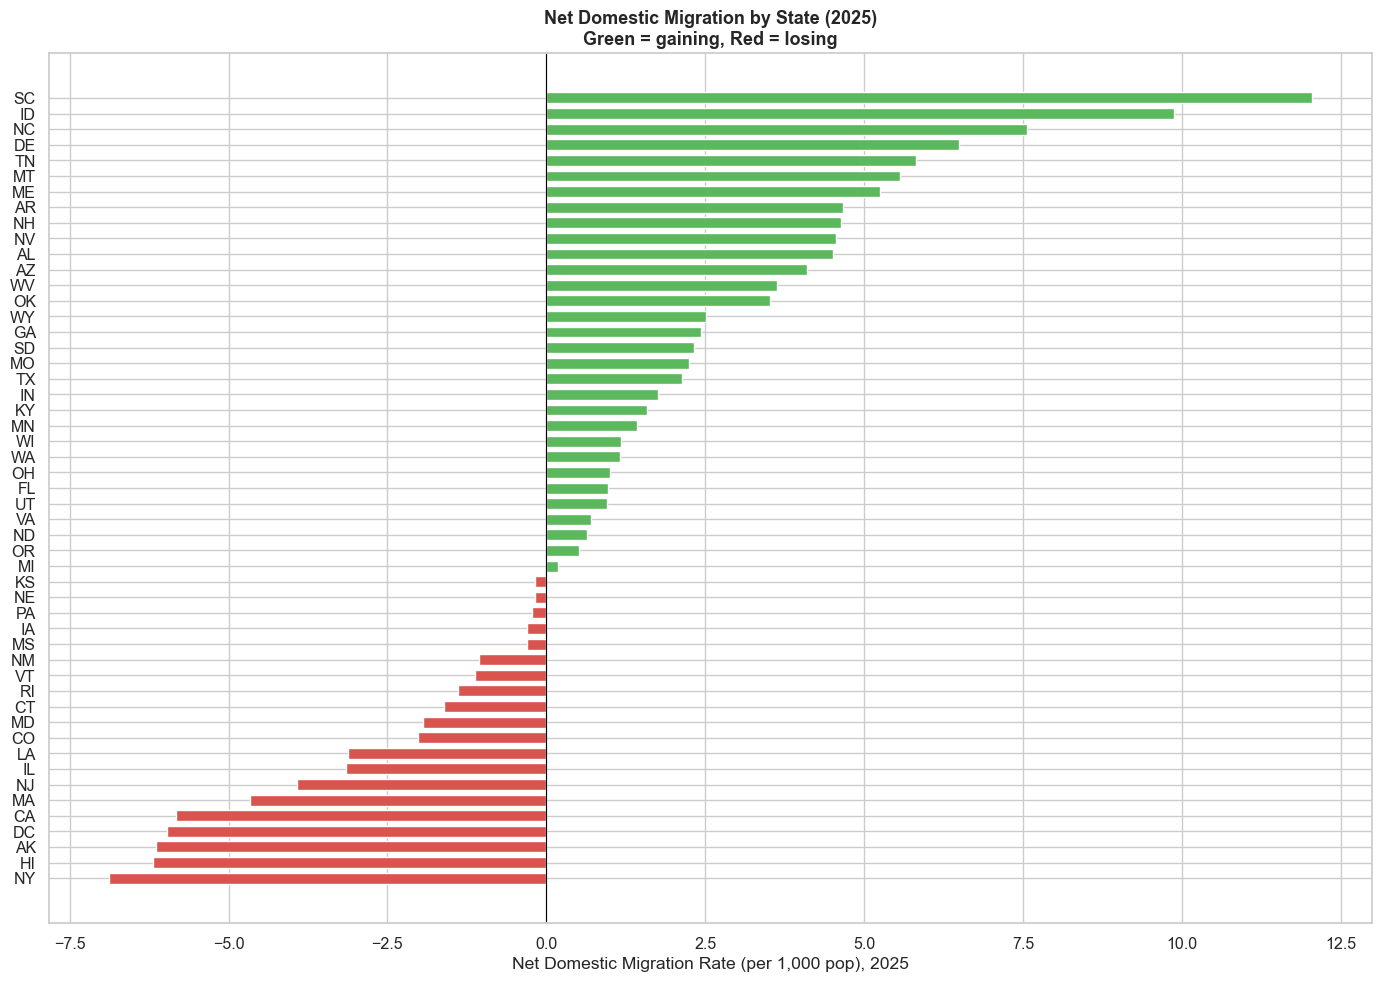

Biggest gainers (2025):
  SC: +12.05 per 1,000
  ID: +9.88 per 1,000
  NC: +7.56 per 1,000
  DE: +6.50 per 1,000
  TN: +5.82 per 1,000

Biggest losers (2025):
  NY: -6.88 per 1,000
  HI: -6.19 per 1,000
  AK: -6.14 per 1,000
  DC: -5.96 per 1,000
  CA: -5.82 per 1,000


In [23]:
# Top migration gainers and losers (most recent year)
latest_yr = mig["year"].max()
latest_mig = mig[mig["year"]==latest_yr].set_index("state")["rdomesticmig"].sort_values()

fig, ax = plt.subplots(figsize=(14, 10))
colors = [PAL["red"] if v < 0 else PAL["green"] for v in latest_mig.values]
ax.barh(latest_mig.index, latest_mig.values, color=colors, edgecolor="white", height=0.7)
ax.axvline(0, color="black", lw=0.8)
ax.set_xlabel(f"Net Domestic Migration Rate (per 1,000 pop), {latest_yr}")
ax.set_title(f"Net Domestic Migration by State ({latest_yr})\nGreen = gaining, Red = losing",
             fontsize=13, fontweight="bold")
plt.tight_layout(); plt.savefig(os.path.join(EDA, "07_migration_by_state.png"), dpi=150, bbox_inches="tight"); plt.show()

print(f"Biggest gainers ({latest_yr}):")
for st in latest_mig.tail(5).index[::-1]:
    print(f"  {st}: {latest_mig[st]:+.2f} per 1,000")
print(f"\nBiggest losers ({latest_yr}):")
for st in latest_mig.head(5).index:
    print(f"  {st}: {latest_mig[st]:+.2f} per 1,000")

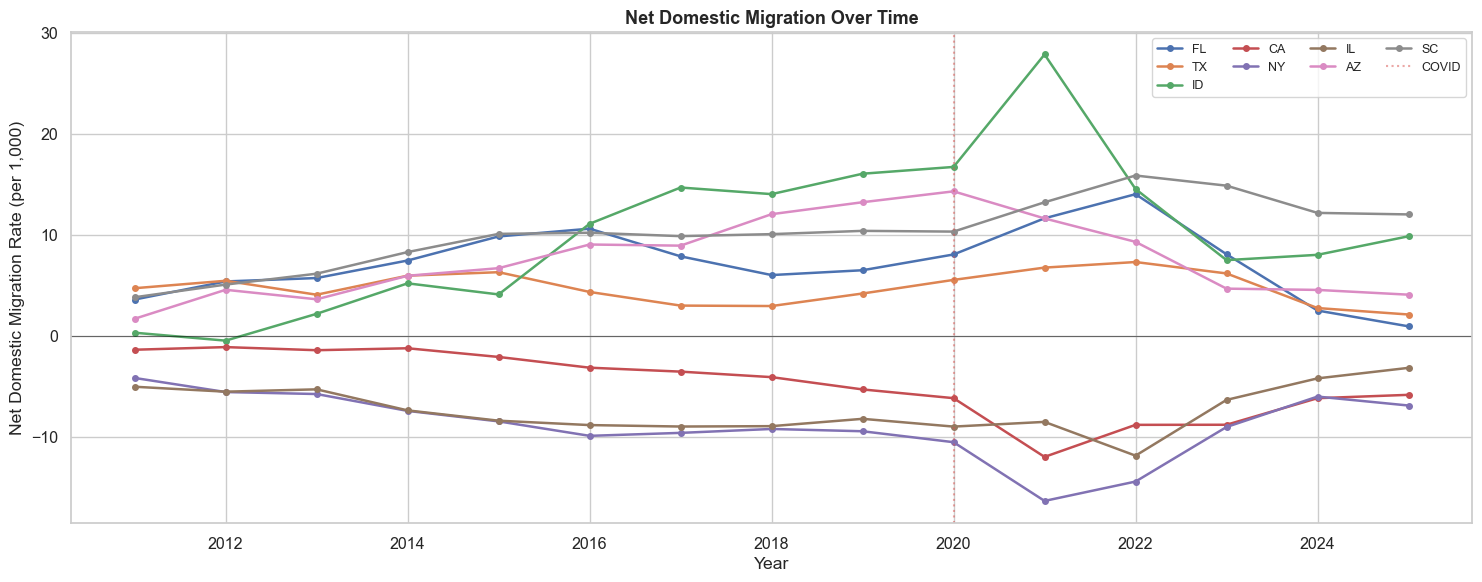

In [24]:
# Migration trends over time for key states
fig, ax = plt.subplots(figsize=(15, 6))
for st in ["FL","TX","ID","CA","NY","IL","AZ","SC"]:
    sub = mig[mig["state"]==st].sort_values("year")
    ax.plot(sub["year"], sub["rdomesticmig"], label=st, lw=1.8, marker="o", ms=4)

ax.axhline(0, color="black", lw=0.8, alpha=0.5)
ax.axvline(2020, color=PAL["red"], ls=":", alpha=0.5, label="COVID")
ax.set_xlabel("Year"); ax.set_ylabel("Net Domestic Migration Rate (per 1,000)")
ax.set_title("Net Domestic Migration Over Time", fontsize=13, fontweight="bold")
ax.legend(ncol=4, fontsize=9)
plt.tight_layout(); plt.savefig(os.path.join(EDA, "08_migration_trends.png"), dpi=150, bbox_inches="tight"); plt.show()

---
## 9. Cross-Dataset Coverage Alignment

The panel can only span where **all** datasets overlap.

In [31]:
align = pd.DataFrame(coverage).T
align.index.name = "Dataset"
display(align)

,states,start,end,freq
Dataset,,,,
FHFA Rates,51,2013 Q1,2025Q3,Quarterly
Permits,51,2000-01-01,2025-12-01,Monthly
FHFA HPI,51,2000-01-01,2025-10-01,Quarterly (ffill)
Unemployment,51,2000-01-01,2025-12-01,Monthly
National,N/A,2000-01-01,2025-12-01,Monthly
Zillow ZHVI,51,2000-01-31,2026-02-28,Monthly
Realtor.com,51,2016-07-01,2026-02-01,Monthly
Census Migration,51,2011,2025,Annual


---
## 10. Pre-Merge Summary

### Data Quality Scorecard

In [28]:
print(f"{'Dataset':<20s} {'States':>7s} {'Nulls':>8s} {'Dupes':>7s} {'Status':>10s}")
print("-" * 55)
checks = [
    ("FHFA Rates", 51, fhfa.isnull().sum().sum(), fhfa.duplicated().sum()),
    ("Permits", 51, permits.isnull().sum().sum(), 0),
    ("FHFA HPI", 51, hpi.isnull().sum().sum(), 0),
    ("Unemployment", 51, unemp.isnull().sum().sum(), 0),
    ("National", "N/A", natl.isnull().sum().sum(), 0),
    ("Zillow", 51, zillow[date_cols].isnull().sum().sum(), 0),
    ("Realtor.com", 51, 0, rdc.duplicated().sum()),
    ("Census Migration", mig["state"].nunique(), mig["rdomesticmig"].isnull().sum(), 0),
]
for name, st, nulls, dupes in checks:
    status = "\u2713 CLEAN" if nulls < 50 and dupes == 0 else "\u26a0 CHECK"
    print(f"  {name:<18s} {str(st):>7s} {nulls:>8,} {dupes:>7,} {status:>10s}")

Dataset               States    Nulls   Dupes     Status
-------------------------------------------------------
  FHFA Rates              51   41,616       0    ⚠ CHECK
  Permits                 51        1       0    ✓ CLEAN
  FHFA HPI                51        0       0    ✓ CLEAN
  Unemployment            51       51       0    ⚠ CHECK
  National               N/A        1       0    ✓ CLEAN
  Zillow                  51      228       0    ⚠ CHECK
  Realtor.com             51        0       0    ✓ CLEAN
  Census Migration        51        0       0    ✓ CLEAN


In [27]:
print("Diagnostic plots saved to output/eda/:")
for f in sorted(os.listdir(EDA)):
    if f.endswith(".png"):
        print(f"  {f}")
print("\n\u2713 Pre-merge EDA complete. Proceed to panel construction notebook.")

Diagnostic plots saved to output/eda/:
  01_fhfa_ave_intrate_dist.png
  02_fhfa_ave_intrate_states.png
  03_fhfa_rate_dist_stacked.png
  04_permits_overview.png
  05_national_series.png
  06_realtor_listings.png
  07_migration_by_state.png
  08_migration_trends.png

✓ Pre-merge EDA complete. Proceed to panel construction notebook.
